In [1]:
from argparse import ArgumentParser
import xarray as xr
from matplotlib import pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import sys

sys.path.insert(
    1, "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/evaluation"
)
import plot_utils as plot
import numpy as np

save_folder = "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/new_values/"


def create_folder_if_not_exists(folder):
    from pathlib import Path

    Path(folder).mkdir(parents=True, exist_ok=True)


def get_temporal_index_in_dataset(timestamp, ds):
    """
    Returns the integer index of a given timestamp in an xarray Dataset
    that may use non-Gregorian calendars (e.g., 360_day).

    timestamp: cftime.Datetime object or a string parseable by cftime
    ds: xarray.Dataset or DataArray with a 'time' coordinate
    """

    # Iterate over time coordinates to find match
    for i, t in enumerate(ds.time.values):
        if t == timestamp:
            return i

    # If not found, raise error
    raise ValueError(f"Timestamp {timestamp} not found in dataset time axis.")


def get_true_data_matching_forecast_timestamps(
    ds_truth, ds_forecast, prediction_steps
):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = (
        get_temporal_index_in_dataset(first_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    idx_truth_last = (
        get_temporal_index_in_dataset(last_timestamp_forecast, ds_truth)
        + prediction_steps
        + 1
    )
    new_forecast = ds_forecast.copy().isel(
        prediction_timedelta=prediction_steps
    )
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))

    for t in range(len(new_forecast.time.values) - 1):
        if (
            not str(
                new_forecast.time.values[t + 1] - new_forecast.time.values[t]
            )
            == "12:00:00"
        ):
            print(
                f"Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}"
            )
    new_forecast = new_forecast.assign_coords({"time": new_truth["time"]})
    return new_truth, new_forecast


def get_stacked_true_data_matching_forecast_timestamps(ds_truth, ds_forecast):
    """
    prediction_steps should be 0 based -> 0 means using the first prediction of the model for that timestamp
    """
    first_timestamp_forecast = ds_forecast.time[0].values
    last_timestamp_forecast = ds_forecast.time[-1].values
    idx_truth_first = get_temporal_index_in_dataset(
        first_timestamp_forecast, ds_truth
    )
    idx_truth_last = get_temporal_index_in_dataset(
        last_timestamp_forecast, ds_truth
    )
    new_forecast = ds_forecast.copy()
    new_truth = ds_truth.isel(
        time=slice(idx_truth_first, idx_truth_last + 1)
    ).isel(time=slice(0, None, 2))
    new_forecast = new_forecast.sortby("time")
    _, index = np.unique(new_forecast["time"], return_index=True)
    new_forecast = new_forecast.isel(time=np.sort(index))
    new_forecast = new_forecast.chunk({"latitude": -1, "longitude": -1, "time": 50})
    new_truth = new_truth.chunk({"latitude": -1, "longitude": -1, "time": 50})
    # for t in range(len(new_forecast.time.values)-1):
    #     if not str(new_forecast.time.values[t+1] - new_forecast.time.values[t]) == '12:00:00':
    #         print(f'Error with {new_forecast.time.values[t]} and {new_forecast.time.values[t+1]}')
    # new_forecast = new_forecast.assign_coords({'time': new_truth['time']})
    return new_truth, new_forecast


def build_truth_with_leadtime(truth_ds, max_lead_steps=40):
    """
    truth_ds: Dataset with dimension (time, lat, lon, level)
    Creates a dataset with dimension (time, prediction_timedelta, lat, lon, level)

    lead step k uses truth_ds shifted by k steps forward in time.
    """
    truth_ds = truth_ds.chunk({"time": 50})
    lead_times = np.arange(1, max_lead_steps + 1)

    # Build stacked truth array
    truth_list = []
    for k in lead_times:
        truth_shifted = truth_ds.shift(
            time=-k
        )  # shift backwards so truth[t,k] = truth[t+k]
        truth_list.append(truth_shifted)

    # Combine along new dimension
    truth_with_lead = xr.concat(truth_list, dim="prediction_timedelta")

    # Assign actual timedelta
    truth_with_lead = truth_with_lead.assign_coords(
        prediction_timedelta=xr.DataArray(
            (lead_times * np.timedelta64(6, "h")).astype("timedelta64[ns]"),
            dims=("prediction_timedelta",),
        )
    )

    # Drop times near the end that became NaN
    truth_with_lead = truth_with_lead.dropna(dim="time", how="any")

    return truth_with_lead

In [2]:
ds = xr.open_zarr('new_values/rmse_maps_z64_future.zarr', decode_timedelta=True)
ds128 = xr.open_zarr('new_values/rmse_maps_z128_future.zarr', decode_timedelta=True)
print(ds)

<xarray.Dataset> Size: 10MB
Dimensions:                  (prediction_timedelta: 40, longitude: 128,
                              latitude: 64)
Coordinates:
  * latitude                 (latitude) float64 512B -90.0 -87.14 ... 87.14 90.0
  * longitude                (longitude) float64 1kB 0.0 2.812 ... 354.4 357.2
  * prediction_timedelta     (prediction_timedelta) timedelta64[ns] 320B 06:0...
Data variables:
    geopotential_500         (prediction_timedelta, longitude, latitude) float32 1MB dask.array<chunksize=(1, 128, 64), meta=np.ndarray>
    relative_vorticity       (prediction_timedelta, longitude, latitude) float32 1MB dask.array<chunksize=(1, 128, 64), meta=np.ndarray>
    specific_humidity        (prediction_timedelta, longitude, latitude) float32 1MB dask.array<chunksize=(1, 128, 64), meta=np.ndarray>
    surface_temperature      (prediction_timedelta, longitude, latitude) float32 1MB dask.array<chunksize=(1, 128, 64), meta=np.ndarray>
    temperature              (predicti

In [5]:
plot.plot_single_plot(ds['temperature'].isel(prediction_timedelta=-1).T, f'Temperature at 850hPa, Average RMSE (z64, 2097-2100)', 'RMSE', (0,200), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/temp_z64", f'')
plot.plot_single_plot(ds128['temperature'].isel(prediction_timedelta=-1).T, f'Temperature at 850hPa, Average RMSE (z128, 2097-2100)', 'RMSE', (0,200), 'viridis', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/temp_z128", f'')

/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


In [23]:
def compute_rmse_for_variable(truth_ds, forecast_ds, key, weights, all_rmse, rmse_maps, past, current_model_resolution, var_start, fix_masks=False):

    display_name, _, variable, plevel, _ = plot.KEY_VARIABLES_UKESM[key]

    if fix_masks and ((not plevel) or (plevel <= 500)):
        print(f"Skipping {display_name} because of fix_masks==True")
        return
    print(f"Current var (RMSE): {display_name}")

    # Select variable
    truth = truth_ds[variable]
    forecast = forecast_ds[variable]

    # Level selection
    if plevel is not None:
        truth = truth.sel(level=plevel)
        forecast = forecast.sel(level=plevel)

        if plevel > 500:
            truth = plot.get_masked_ukesm_data(
                truth, plevel=plevel
            )
            forecast = plot.get_masked_ukesm_data(
                forecast, plevel=plevel
            )



    me_map = (forecast - truth).mean(dim="time")

    if plevel:
        rmse_maps[variable] = me_map.drop_vars("level")
    else:
        rmse_maps[variable] = me_map

    print(f"RMSE map for {variable}: {rmse_maps[variable].shape}")


    ds_rmse_maps = xr.Dataset({var: rmse_maps[var] for var in rmse_maps})

    plot.plot_single_plot(ds_rmse_maps['temperature'].isel(prediction_timedelta=-1).T, f'Regrid Boolean Mask', 'valid (regridded)', None, 'coolwarm', "/home/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/eval_ukesm/", f'step_3', show=True)


In [ ]:
model_idx=0
past_int=0
var_start=0

past = False if past_int == 0 else True

model_resolution = [
    "z64",
    "z128",
    "z256",
    "z64 hierarchical",
    "persistence",
]

current_model_resolution = model_resolution[model_idx]


selected_model_past = plot.PAST_MODELS_UKESM[model_idx]
selected_model_future = plot.FUTURE_MODELS_UKESM[model_idx]
print(f'Evaluating model: {selected_model_past["model_name"]}')

base_save_folder_past = selected_model_past["plot_folder"]
base_save_folder_future = selected_model_future["plot_folder"]

ukesm_past_forecasts = plot.open_zarr_ukesm(
    selected_model_past["forecasts"]
)
ukesm_future_forecasts = plot.open_zarr_ukesm(
    selected_model_future["forecasts"]
)

ukesm_past_truth = plot.open_zarr_ukesm(selected_model_past["ground_truth"])
ukesm_future_truth = plot.open_zarr_ukesm(
    selected_model_future["ground_truth"]
)

create_folder_if_not_exists(base_save_folder_past)
create_folder_if_not_exists(base_save_folder_future)

print("Stacking truth...")
truth_stacked = build_truth_with_leadtime(
    ukesm_past_truth if past else ukesm_future_truth
)

print("Selecting matching truth / forecasts...")
truth_ds, forecast_ds = get_stacked_true_data_matching_forecast_timestamps(
    truth_stacked, ukesm_past_forecasts if past else ukesm_future_forecasts
)

print("Preparing weights...")
lat = truth_ds["latitude"]
weights = np.cos(np.deg2rad(lat))
weights = xr.DataArray(weights, coords={"latitude": lat}, dims=["latitude"])
weights = weights / weights.sum()

all_rmse = {}
rmse_maps = {}
all_r2 = {}
r2_maps = {}

Current var (RMSE): Temperature at 850hPa
RMSE map for temperature: (40, 128, 64)


/hkfs/home/project/hk-project-pai00005/xo8179/neural_lam_fork/neural-lam/venv/lib64/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


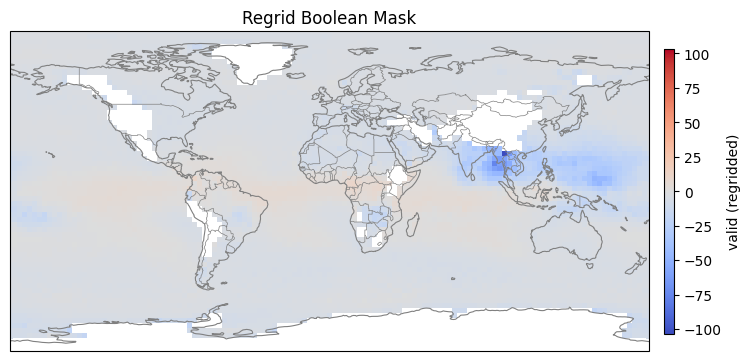

In [24]:
for key in range(1,2):
    compute_rmse_for_variable(truth_ds, forecast_ds, key, weights, all_rmse, rmse_maps, past, current_model_resolution, var_start)